# **Encoding Categorical Data**

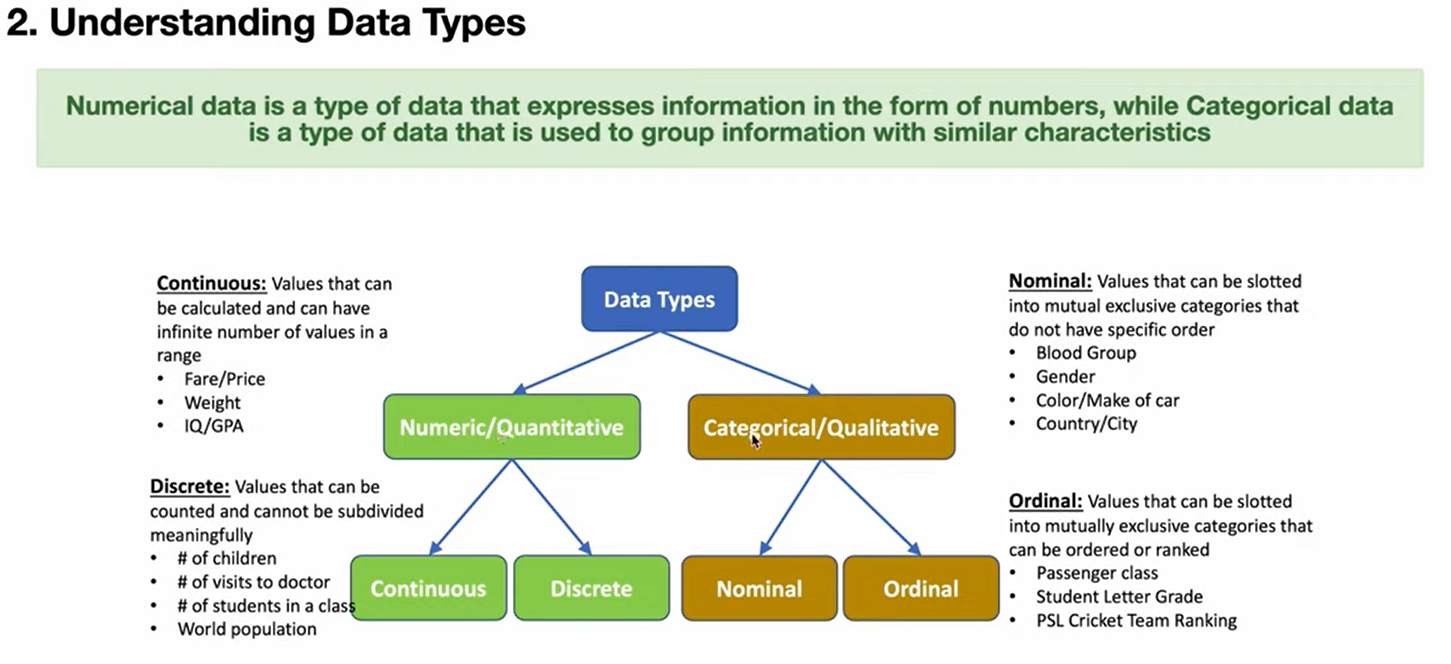

**1. Nominal Data**

Definition: Categories without any natural order.

Colors: Red, Blue, Green

Gender: Male, Female

Types of pets: Dog, Cat, Bird

Key Point: You can't say one is greater or less than another. They are just labels.

**2. Ordinal Data**

Definition: Categories with a natural order, but the differences between the categories are not measurable.

Education level: High school < Bachelor < Master < PhD

Satisfaction rating: Poor < Fair < Good < Excellent

Key Point: You can rank them, but you can't measure the exact difference between them.

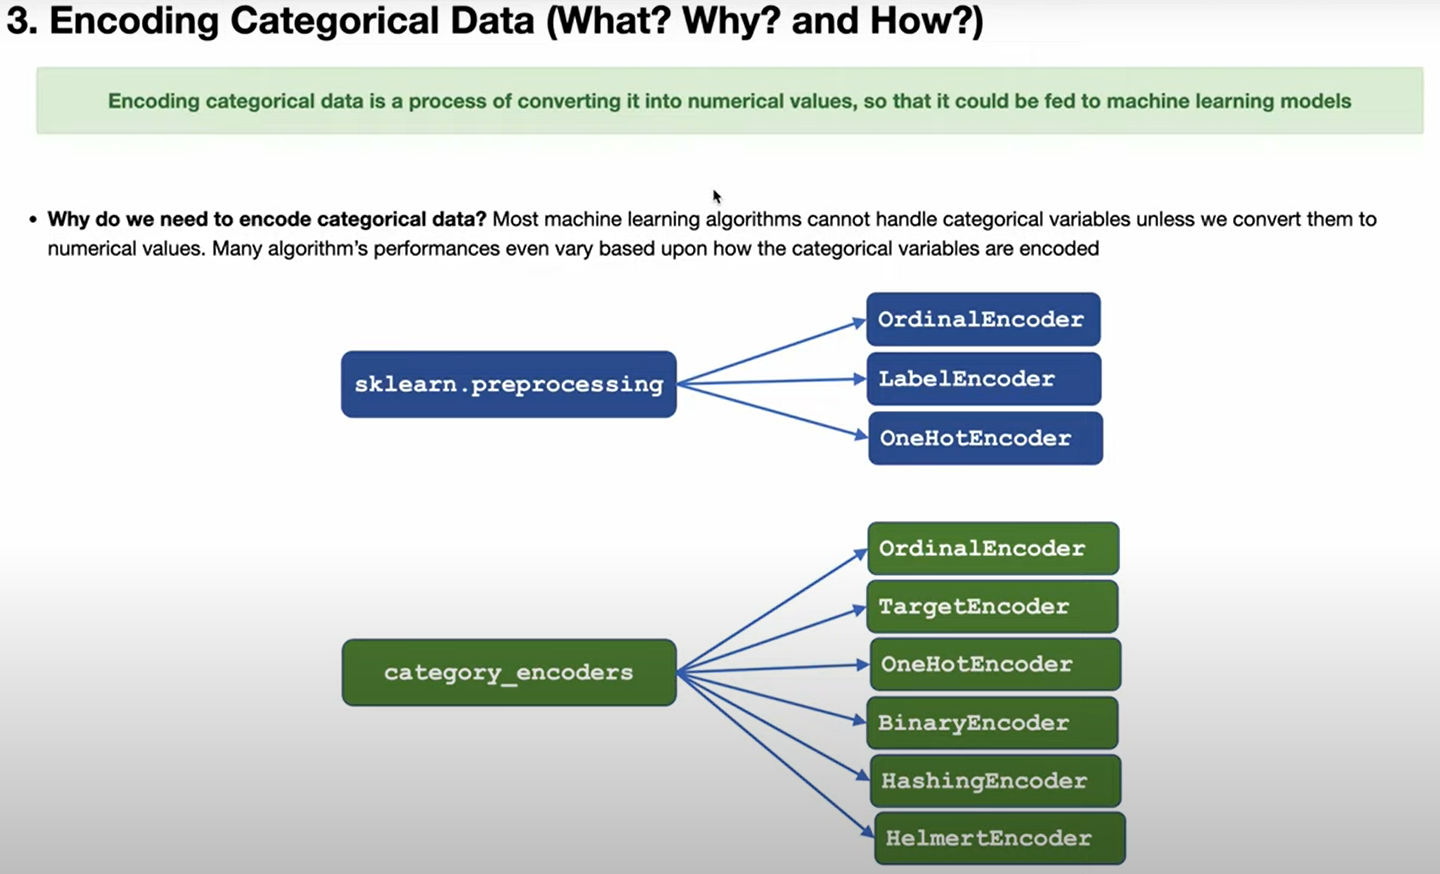

In [63]:

import numpy as np
import pandas as pd
df = pd.read_csv(r"D:\Codes\MachineLearning\Datasets\disease.csv")
df.sample(n=5, random_state=42)

,gender,city,age,bp,cough,disease
83,Female,Lahore,17.0,normal,Mild,No
53,Male,Islamabad,83.0,high,Mild,Yes
70,Female,Islamabad,68.0,normal,Strong,No
45,Male,Shaikhupura,72.0,normal,Mild,No
44,Male,Islamabad,20.0,normal,Strong,No


In [64]:
df.nunique()

gender      2
city        4
age        54
bp          3
cough       3
disease     2
dtype: int64

In [65]:
df["city"].value_counts()

city
Lahore         32
Shaikhupura    30
Islamabad      22
Karachi        16
Name: count, dtype: int64

## **Sklearn Lable and Ordinal Encoders** 

Applying Label Encoder on Target Label

In [66]:
y = df.iloc[:, -1]
y

0     Yes
1      No
2      No
3     Yes
4      No
     ... 
95     No
96    Yes
97     No
98     No
99    Yes
Name: disease, Length: 100, dtype: object

In [67]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
arrayDisease = le.fit_transform(y)


In [68]:
arrayDisease.dtype

dtype('int64')

In [69]:
le.classes_

array(['No', 'Yes'], dtype=object)

In [70]:
arrayDisease

array([1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0,
       0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1])

In [71]:
x_bp_cough = df.iloc[:, 3:5]

In [72]:
x_bp_cough.head()

,bp,cough
0,low,Moderate
1,low,Mild
2,normal,Strong
3,high,Moderate
4,high,Mild


In [73]:
from sklearn.preprocessing import OrdinalEncoder
oe = OrdinalEncoder()
# oe = OrdinalEncoder(categories=[["low", "normal", "high"], ["mild", "moderate", "Strong"]])

In [74]:
array_bp_cough = oe.fit_transform(x_bp_cough) 
oe.categories_

[array(['high', 'low', 'normal'], dtype=object),
 array(['Mild', 'Moderate', 'Strong'], dtype=object)]

In [75]:
array_bp_cough

array([[1., 1.],
       [1., 0.],
       [2., 2.],
       [0., 1.],
       [0., 0.],
       [0., 0.],
       [2., 2.],
       [2., 1.],
       [0., 2.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [2., 2.],
       [1., 0.],
       [1., 0.],
       [2., 2.],
       [2., 0.],
       [1., 1.],
       [0., 0.],
       [0., 2.],
       [1., 2.],
       [0., 1.],
       [2., 2.],
       [2., 0.],
       [2., 1.],
       [2., 0.],
       [0., 1.],
       [2., 2.],
       [2., 0.],
       [0., 1.],
       [1., 0.],
       [2., 0.],
       [0., 2.],
       [2., 1.],
       [1., 0.],
       [2., 2.],
       [2., 0.],
       [2., 1.],
       [0., 0.],
       [2., 1.],
       [2., 0.],
       [1., 0.],
       [1., 0.],
       [1., 1.],
       [2., 2.],
       [2., 0.],
       [2., 1.],
       [2., 0.],
       [1., 1.],
       [1., 0.],
       [2., 0.],
       [0., 1.],
       [0., 2.],
       [0., 0.],
       [2., 0.],
       [2., 0.],
       [0., 2.],
       [1., 2.],
       [1., 2.

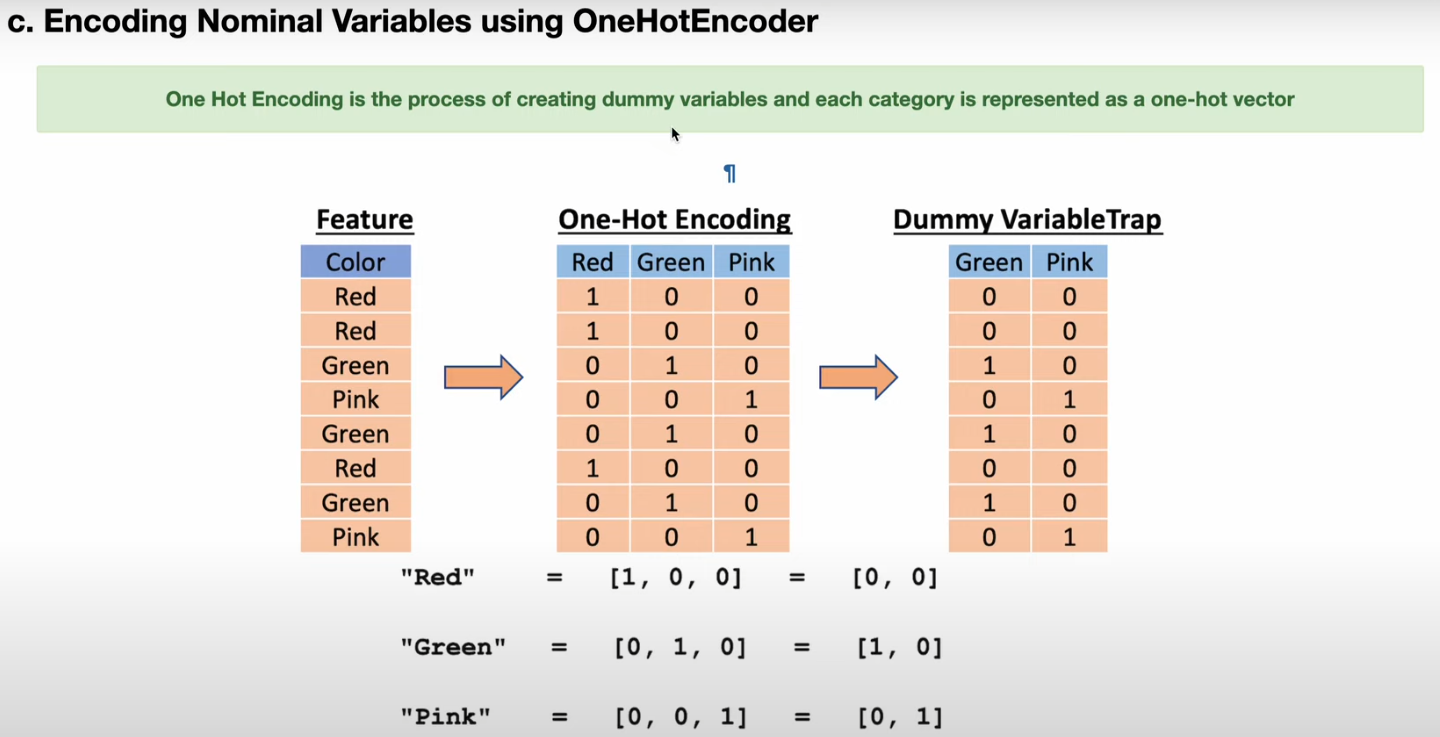

In [76]:
x_gender = df.iloc[:, 0:1]
x_gender.head()

,gender
0,Male
1,Male
2,Male
3,Female
4,Female


In [77]:
pd.get_dummies(data=df, columns=['gender', 'city'], drop_first=True) 

# 000 islamabad
# 100 karachi
# 010 lahore 
# 001 Shaikhupura

# 1 male 
# 0 female

,age,bp,cough,disease,gender_Male,city_Karachi,city_Lahore,city_Shaikhupura
0,60.0,low,Moderate,Yes,True,False,True,False
1,27.0,low,Mild,No,True,False,False,False
2,NaN,normal,Strong,No,True,False,False,False
3,31.0,high,Moderate,Yes,False,False,True,False
4,65.0,high,Mild,No,False,True,False,False
...,...,...,...,...,...,...,...,...
95,NaN,normal,Mild,No,False,False,False,True
96,51.0,high,Strong,Yes,False,False,True,False
97,20.0,normal,Mild,No,False,False,False,True
98,5.0,low,Moderate,No,False,True,False,False


In [78]:
x_gender_city = df.iloc[:,0:2]
x_gender_city

,gender,city
0,Male,Lahore
1,Male,Islamabad
2,Male,Islamabad
3,Female,Lahore
4,Female,Karachi
...,...,...
95,Female,Shaikhupura
96,Female,Lahore
97,Female,Shaikhupura
98,Female,Karachi


In [79]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(drop='first', dtype=np.int32)

In [80]:
sparse_matrix = ohe.fit_transform(x_gender_city)

In [81]:
array_gender_city= sparse_matrix.toarray()

In [82]:
array_gender_city.shape

(100, 4)

In [83]:
array_gender_city

array([[1, 0, 1, 0],
       [1, 0, 0, 0],
       [1, 0, 0, 0],
       [0, 0, 1, 0],
       [0, 1, 0, 0],
       [0, 0, 0, 1],
       [1, 0, 0, 1],
       [0, 1, 0, 0],
       [0, 0, 0, 1],
       [0, 0, 0, 0],
       [0, 0, 0, 0],
       [0, 1, 0, 0],
       [0, 0, 1, 0],
       [1, 0, 0, 1],
       [1, 0, 0, 1],
       [1, 0, 1, 0],
       [0, 0, 1, 0],
       [0, 0, 0, 0],
       [0, 0, 0, 1],
       [0, 0, 0, 1],
       [1, 0, 0, 1],
       [1, 0, 0, 1],
       [0, 0, 1, 0],
       [0, 0, 0, 0],
       [0, 0, 1, 0],
       [1, 1, 0, 0],
       [0, 0, 1, 0],
       [0, 0, 0, 0],
       [1, 0, 1, 0],
       [0, 1, 0, 0],
       [1, 0, 0, 0],
       [1, 0, 1, 0],
       [0, 0, 0, 0],
       [0, 0, 1, 0],
       [1, 1, 0, 0],
       [0, 0, 0, 1],
       [0, 0, 0, 1],
       [1, 0, 1, 0],
       [0, 0, 0, 0],
       [0, 0, 1, 0],
       [0, 0, 0, 0],
       [1, 0, 1, 0],
       [1, 0, 0, 0],
       [0, 0, 0, 1],
       [1, 0, 0, 0],
       [1, 0, 0, 1],
       [0, 1, 0, 0],
       [0, 0,

# **Doing Train Test Split**  

In [84]:
x = df.drop("disease", axis=1)
y = df["disease"]

In [85]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
len(X_train), len(X_test), len(y_train), len(y_test)

(80, 20, 80, 20)

In [86]:
ohe = OneHotEncoder(drop='first', dtype=np.int32)

spears_train_gender_city = ohe.fit_transform(X_train[['gender', 'city']])
spears_test_gender_city = ohe.transform(X_test[['gender', 'city']])

x_train_gender_city= spears_train_gender_city.toarray()
x_test_gender_city= spears_test_gender_city.toarray()

x_train_gender_city.shape,  x_test_gender_city.shape

((80, 4), (20, 4))

## **Applying Label Encoder on Disease.**

In [87]:
le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_test = le.fit_transform(y_test)


y_train.shape, y_test.shape

((80,), (20,))

In [88]:
y_test

array([0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0])

In [89]:
from sklearn.impute import SimpleImputer
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   gender   100 non-null    object 
 1   city     100 non-null    object 
 2   age      87 non-null     float64
 3   bp       100 non-null    object 
 4   cough    100 non-null    object 
 5   disease  100 non-null    object 
dtypes: float64(1), object(5)
memory usage: 4.8+ KB


In [90]:
df.age.isna().sum()

np.int64(13)

In [95]:
si = SimpleImputer(missing_values=np.nan, strategy='mean')

si.fit(X_train[["age"]])

X_train_age = si.transform(X_train[['age']])
X_test_age =  si.transform(X_test[['age']])


X_train_age.shape, X_test_age.shape

((80, 1), (20, 1))

## **Combining All the Results**